In [2]:
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np

# LSN Exercises 04
## Molecular dynamics


Gabriele Borroni (14768A)


---

## Statistical physics

Statistical physics is the branch of physics that bridges the microscopic world with the macroscopic one using statistics.

 Even the simplest macroscopic system contains on the order of $\sim 10^23$ particles, making it not only impossible but also meaningless to track the motion of each individual constituent when studying the system as a whole.

By leveraging the connection with thermodynamics, it's possible to reduce this enormous amount of degrees of freedom to just a handful of **state variables**-measurable macroscopic quantities that effectively summarize the collective behavior of all microscopic components.

Thus, a system can be described in terms of:

-**Macroscopic state**: the real-world measurable one, caracterized by variables such as energy E, temperature T, volume V, number of particles N.

-**Microscopic state**: defined as a configuration of points in the phase spase (q,p). For every macroscopic state, there exist many compatible microscopic configurations.

Since describing the exact microscopic state of each particle is practically unfeasible — and the number of microstates corresponding to a single macrostate is extremely large — **microcanonical ensemble theory** relies on the assumption that, for a given macrostate, **all compatible microstates are equally probable**.

In a microcanonical ensemble, for all the considerations made above, a good way to evaluate macro quantities based on the microstate is to compute the **ensemble average**, namely an average over all the possible micro-configurations compatible with the macro-state at a fixed time instant. For a generic observable A:
$$
\langle A \rangle_E = \int A(q, p)\, \rho(q, p)\, d^{3N}q\, d^{3N}p

$$
Where $\rho(q,p)$ is the representative points density in the phase space.
Another, more realistic quantity, is the **time average**, which corresponds to what it's actually measured in experiments. Given initial conditions $A(q(t_0),p(t_0))=A_0$, it is defined as:

$$
\langle A\rangle_t= \frac{1}{\Delta t}\int_{t_0}^{t_0+\Delta t} A(q(t), p(t))dt
$$


The **ergodic hypothesis** states that, for $\Delta t \to\infty$ the ensemble average and the time average coincide. This means that if one waits enough time, the system prepared in an appropriate starting condition will explore all the space of the possible microscopic configurations compatible with a given macro-state.

In practical simulations, only one trajectory is computed. The ergodic hypothesis allows to extract meaningful macroscopic information from this single time evolution, assuming that it effectively samples the relevant regions of phase space.

## Molecular dynamics
In this exercise, the focus is on a **rarefied gas in an isolated box**, a system with fixed $(N,V,T)$.

The idea of molecular dynamics is to test statistical physics by simulating the time dependent behaviour of a system of particles. Laws of motion are used to simulate every particle position and velocity at each time step, with the aim to extract macroscopic quantities from the system by using statistical physics.

The code implements a simulation of the particles using an Hamiltonian based on the **Lennard-Jones potential**, and the movements are simulated using the **Verlet algorithm**, based on taylor expantion of the position vector $\vec{r}$:
$$
\vec{r}(t+\delta t)= 2\vec{r}(t)- \vec{r}(t-\delta t) +\delta t^2 \vec{a}(t)
$$

**Periodic boundary conditions** are applied: the "box" hasn't solid walls, if a particles tries to hit one of them, it will reappear on the opposite side.

## 2.1/2.2: The Maxwell-Boltzmann distribution

For an ideal gas at fixed temperature, statistical physics provides a way to get the **particles velocity distrubion**, and it's called the Maxwell-Boltzmann distribution (in reduced Lennard-jones units):

$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

If all the considerations done before hold, by starting a molecular dynamics simulation with fcc (crystalline) initial configuration of molecules and with initial **delta distribution for velocities**, after a certain number of time steps, the observed velocity distribution observed should converge to the Maxwell-Boltzmann one. This is what's been done with the argon parameters: $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu in gas-phase conditions $\rho^\star = 0.05$, $T^\star \sim  2.0$.

The code runs the simulation with the Verlet algorithm and the velocities of the particles are recorded in an histogram. Results are as always obtained using data blocking.


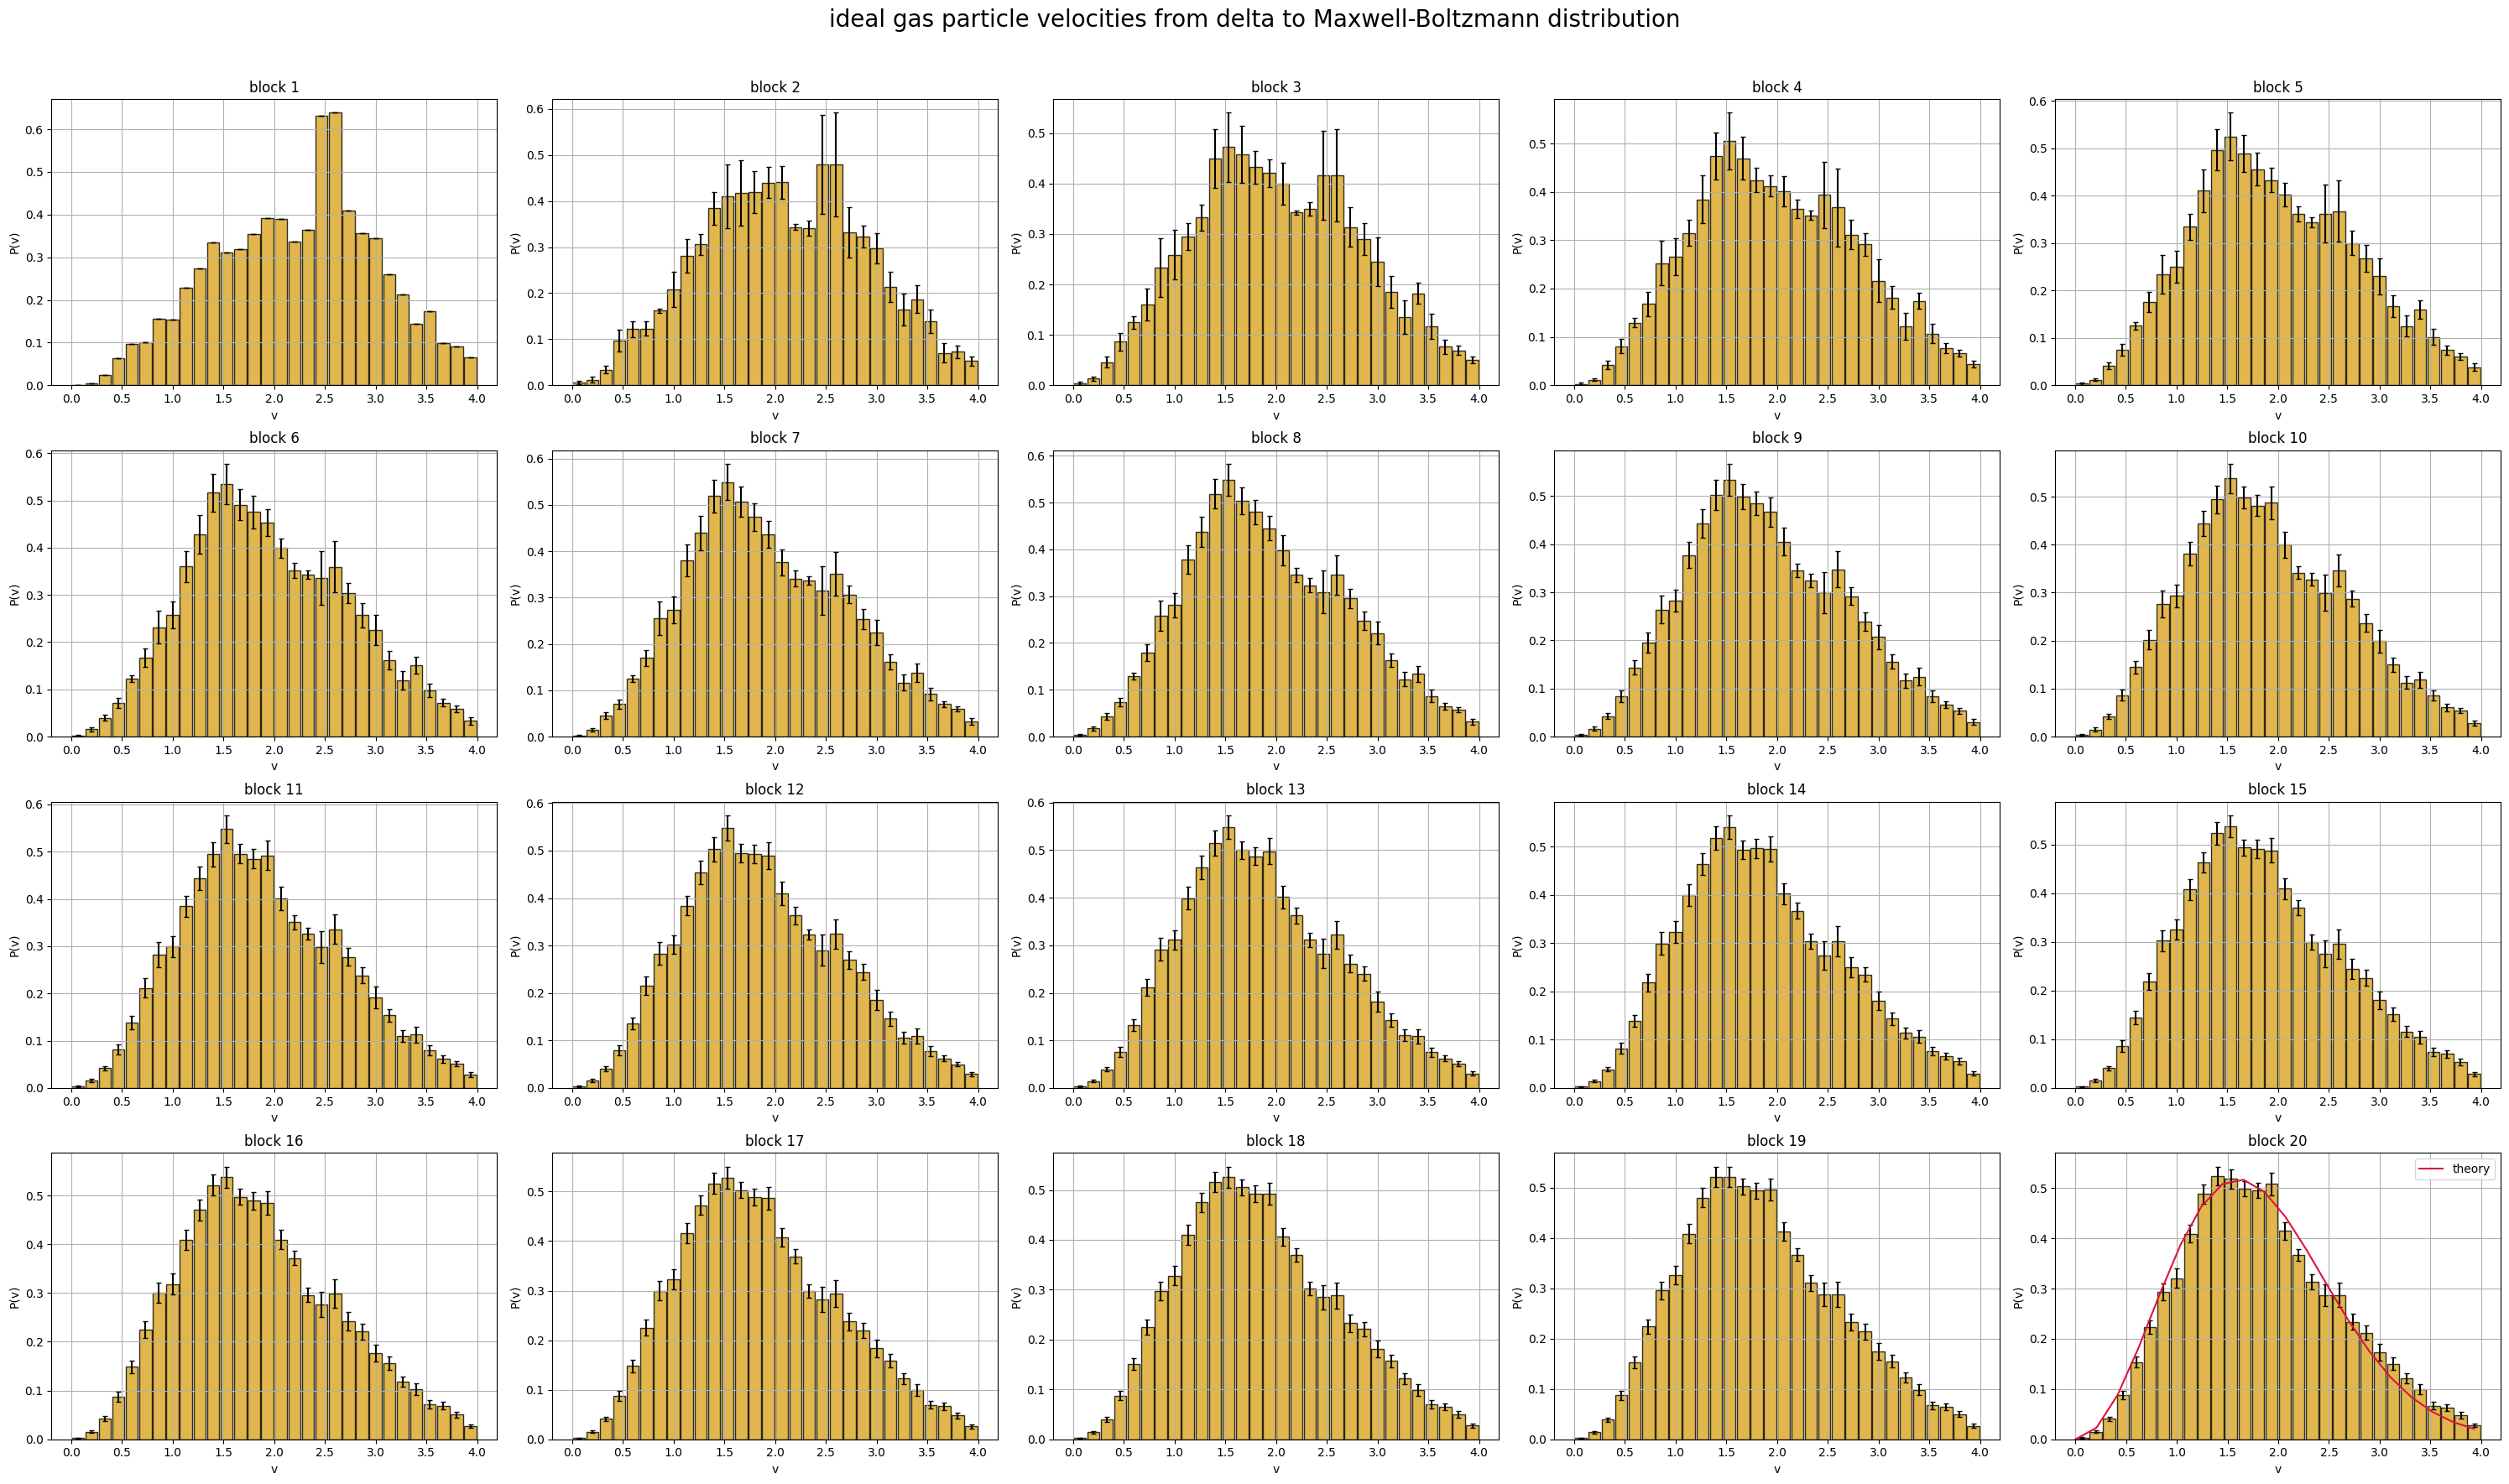

In [11]:

def maxwell_boltzmann(v, T, m=1.0):
    coeff = 4 * np.pi * (m / (2 * np.pi * T))**1.5
    f_MB = coeff * v**2 * np.exp(-m * v**2 / (2 * T))
    return f_MB
data = np.loadtxt("4.2/NSL_SIMULATOR/OUTPUT/pofv.dat")
Temp=np.loadtxt("4.2/NSL_SIMULATOR/OUTPUT/temperature.dat")
Final_T=Temp[-1,1]
blocks=np.unique(data[:,0]) 
#plot
fig, axes= plt.subplots(4,5, figsize=(30,18))
axes=axes.flatten()
for blk in range (len(blocks)):
    #ffilter current block's data
        current_block=data[data[:,0]==blk+1]
        v=current_block[:,1]
        pofv=current_block[:,3]
        err=current_block[:,4]
        width = np.min(np.diff(v)) * 0.9 if len(v) > 1 else 1.0
        axes[blk].bar(v, pofv, width=width, color='goldenrod', edgecolor='black', alpha=0.8)
        axes[blk].errorbar( v,pofv, yerr=err, fmt='none', ecolor= 'black', capsize=2)
        axes[blk].set_title(f"block {blk+1}")
        axes[blk].grid(True)
        axes[blk].set_xlabel("v")
        axes[blk].set_ylabel("P(v)")
#plot theoretical function 
x=np.linspace(0,np.max(v),20)
y=maxwell_boltzmann(x, Final_T)
axes[-1].plot(x,y, color='crimson', label="theory")
axes[-1].legend()
fig.suptitle('ideal gas particle velocities from delta to Maxwell-Boltzmann distribution', fontsize=20)
plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()


---
## 4.3: Time inversion
The Verlet algorithm is symmetric with respect to the time variable.
Given this property, one might expect that a molecular dynamics simulation could be reversed in time without issues.

In this section, such a reversal was attempted by running a simulation with restart enabled until time step N, and then restarting it after swapping configuration N with N−1. This operation was intended to reverse the direction of time evolution. However, the system did not return to its initial state.

The reason lies in the second law of thermodynamics, which states that the entropy of an isolated system tends to increase over time.
Reversing time would imply evolving from a high-entropy, disordered configuration back to a low-entropy, ordered one — such as a state with aligned velocities or a perfect FCC lattice. This is statistically almost impossible.

In real physical systems, this irreversibility is due to heat dissipation and microscopic chaos.
In the simulation, however, it is caused by numerical friction — small errors from floating-point approximations that accumulate over time and break the ideal time-reversibility of the integration scheme.
The plots below show the behaviour of some quantities of interest like potential energy and temperutre, with "normal" and reversed time.

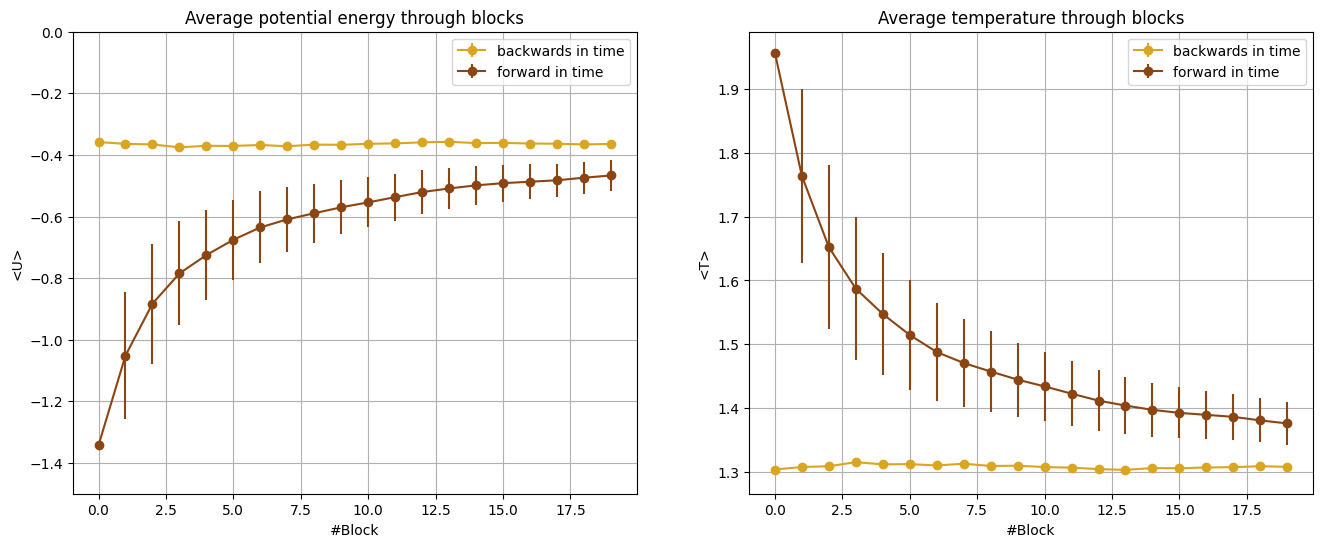

In [22]:
dataU_forward=np.loadtxt("4.3/NSL_SIMULATOR/OUTPUT/potential_energy_direct.dat")
dataT_forward=np.loadtxt("4.3/NSL_SIMULATOR/OUTPUT/temperature_direct.dat")
dataU_backwards=np.loadtxt("4.3/NSL_SIMULATOR/OUTPUT/potential_energy_backwards.dat")
dataT_backwards=np.loadtxt("4.3/NSL_SIMULATOR/OUTPUT/temperature_backwards.dat")
N=np.arange(0,dataU_forward.shape[0]) #get number of blocks
U_forward=dataU_forward[:,2]
errUf=dataU_forward[:,3]
U_backwards=dataU_backwards[:,2]
errUb=dataU_backwards[:,3]
T_forward=dataT_forward[:,2]
errTf=dataT_forward[:,3]
T_backwards=dataT_backwards[:,2]
errTb=dataT_backwards[:,3]
def subplots(ax, x, y, er, ylabel, title, label, color):
    ax.errorbar(x,y,yerr=er, color=color, fmt='-o' ,label=label)
    ax.set_xlabel("#Block")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
fig, ax= plt.subplots(1,2, figsize=(16,6))
ax=ax.flatten()
subplots(ax[0], N, U_backwards, errUb, "<U>","Average potential energy through blocks" , "backwards in time", "goldenrod")
ax[0].set_ylim(-1.5,0)
subplots(ax[0], N, U_forward, errUf, "<U>","Average potential energy through blocks" , "forward in time", "saddlebrown")
subplots(ax[1], N, T_backwards, errTb, "<T>","Average temperature through blocks" , "backwards in time", "goldenrod")
subplots(ax[1], N, T_forward, errTf, "<T>","Average temperature through blocks" , "forward in time", "saddlebrown")



